In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam


def build_car_part_classifier(input_shape=(224, 224, 3)):
    model = models.Sequential()

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation='relu'))

    model.add(layers.Dense(50, activation='softmax'))

    return model

In [5]:

cnn_model = build_car_part_classifier()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,257,522 (84.91 MB)

 Trainable params: 22,257,522 (84.91 MB)

 Non-trainable params: 0 (0.00 B)

The custom Convolutional Neural Network employs a Sequential architecture designed for efficient hierarchical feature extraction. The network processes the input data through three consecutive blocks consisting of Conv2D and MaxPooling2D layers. We progressively increased the filter count (32, 64, and 128) across these blocks to allow the network to initially capture simple shapes and edges, and gradually learn highly complex visual patterns specific to car parts. Simultaneously, the max-pooling layers systematically downsample the spatial dimensions from 222x222 down to 26x26, filtering out noise and keeping the computational load manageable. After the Flatten layer transforms the 3D feature maps into a 1D vector of 86,528 elements, a 256-neuron Dense layer acts as the primary decision-making center. Finally, the architecture concludes with a 50-neuron Dense output layer using a softmax activation to output precise probabilities for each of the 50 car part classes.

In [6]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from data_pipeline import create_dataset_pipeline

# TRAIN_DIR = 'dataset/train'
# VAL_DIR = 'dataset/valid'

TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/valid'

train_ds = create_dataset_pipeline(TRAIN_DIR, batch_size=32, shuffle=True, augment=False)
val_ds = create_dataset_pipeline(VAL_DIR, batch_size=32, shuffle=False, augment=False)

Found 8739 files belonging to 50 classes.
Found 250 files belonging to 50 classes.


In [12]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.2038 - loss: 3.2154 - val_accuracy: 0.3760 - val_loss: 2.3904
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.5931 - loss: 1.5436 - val_accuracy: 0.4560 - val_loss: 2.5378
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.8486 - loss: 0.5362 - val_accuracy: 0.4600 - val_loss: 3.2874
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9579 - loss: 0.1494 - val_accuracy: 0.4400 - val_loss: 3.9343
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9817 - loss: 0.0700 - val_accuracy: 0.4120 - val_loss: 4.6783
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9763 - loss: 0.0814 - val_accuracy: 0.4640 - val_loss: 4.7143
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9851 - loss: 0.0528 - val_accuracy: 0.4920 - val_loss: 4.5640
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9791 - loss: 0.0662 - 

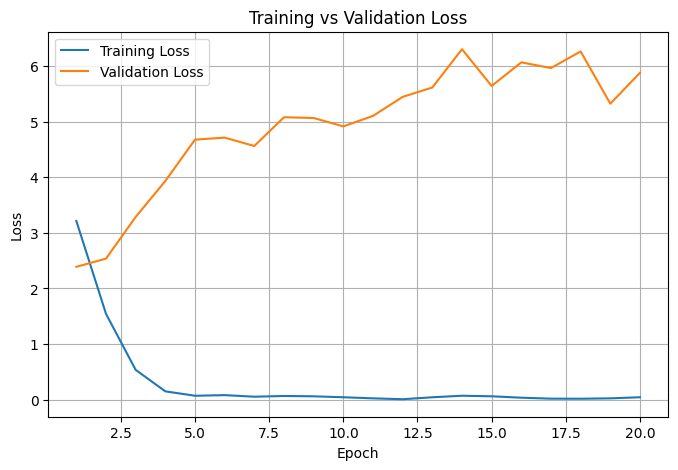

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

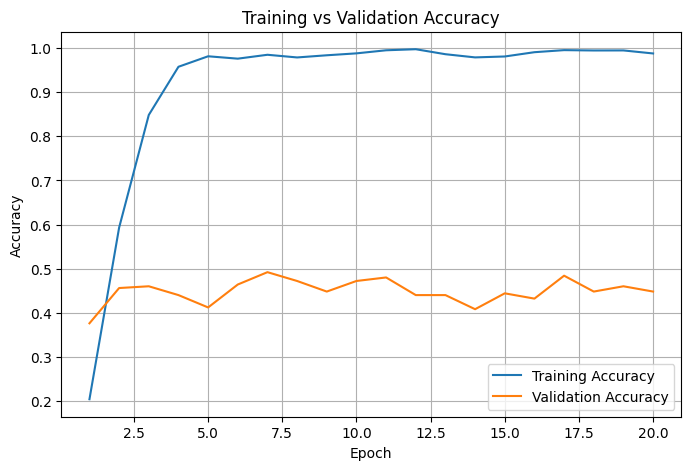

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Is the model overfitting or underfitting?

Obviously, from the charts we can tell the model suffers from overfitting. The validation loss curve keeps increasing with the epochs, while the training loss converges to zero. As expected, the second plot mirrors this: training accuracy climbs up to 99%, which is rarely a good outcome, especially when the validation accuracy oscillates between 0.4 and 0.5. So the clear answer: yes — the model is overfitted.

At which epoch is validation performance best?

I would say somewhere around epoch 8. In the accuracy plot, the validation line increases up to 0.49 at epoch 8, then stays around that value for the rest of the training. In the loss plot, the orange line decreases until the end of the second epoch, then keeps growing. The two criteria disagree, which is a common symptom of overfitting — the model becomes more confident about wrong predictions even when raw accuracy holds. Although performance can be measured directly with the loss function, I think the question targets performance metrics like accuracy.

Research and list at least 3 techniques to prevent overfitting (Dropout, Augmentation, Early Stopping, BatchNorm, Regularization).

Dropout can be applied both to convolutional layers and to the dense layers of a CNN. The typical rate is in the range of 0.2 to 0.3. In convolutional layers we don't have neurons to drop (in an ANN, dropping a neuron means deactivating it — its output becomes zero), so instead we drop an entire feature map that has learned a pattern. This technique relies on the idea that the model is forced not to depend on a specific set of neurons or feature maps. That makes it more robust at inference, in the sense that it generalises better.

Augmentation is the technique we use to fight overfitting by applying transformations (such as rotation of the input images) to the training set. This method helps because the model is forced to recognize the target element (in our case, a car part) despite the noise we introduce on purpose. As a result, the CNN learns to generalise its predictions better. Augmentation is applied only to the training set, not to validation or test data.

Early Stopping is very simple to understand and implement, yet a powerful thing to do when we face overfitting. The concept is: when the performance on the training set keeps improving while the performance on the validation set gets worse, we stop. That's a clue the model is starting to learn the training data too precisely, and we don't want that. In practice, we stop after patience epochs without improvement (to avoid stopping on a random dip), and we restore the model weights from the best epoch.

BatchNorm normalizes the outputs between layers based on the mean and variance computed from the current batch, then rescales them with two trainable parameters (γ and β). It stabilizes training and mitigates the vanishing/exploding gradient problem. The regularizing noise comes from the fact that per-batch statistics vary between batches, so the same input is normalized slightly differently each time. This small variability acts as a mild regularizer — the network cannot rely on exact activation values, which discourages overfitting to specific training patterns and helps the model generalize better.

Regularization is a general term for any technique that adds a constraint to the model in order to prevent overfitting. In the strict sense, it refers to L1/L2 weight regularization, which adds a penalty term to the loss based on the size of the weights. This forces the model to prefer smaller weights, which produce smoother decision boundaries and reduce sensitivity to noise in the training data. As a result, the model is less likely to memorize specific training patterns and generalizes better on unseen data.